# v2 LightGBM Experiment - Sensing + COVID Features

Validates the v2 training pipeline with COVID features added.
Official v2 registration happens when triggered in the retraining phase, register=False.

Comparison to v1:
- Trains on full_train (2017-W37 to 2020-W39) 
- Uses ALL_FEATURES: 22 sensing + 9 COVID items + covid_period = 32 features
- COVID items are NaN for pre-COVID rows 
- COVID-period val/test sets have real COVID survey values
- Same LightGBM architecture as v1 

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("../../")))

import mlflow
import mlflow.lightgbm
import pandas as pd
import matplotlib.pyplot as plt
import os 

from src.models.train_v2 import train_lightgbm_v2, load_v2_splits
from src.features.feature_columns import ALL_FEATURES, SENSING_FEATURES, TARGET

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("mental_health_prediction")
os.environ["MLFLOW_ARTIFACT_UPLOAD_DOWNLOAD_TIMEOUT"] = "300"

# Read v1 best metrics from MLflow 
client = mlflow.tracking.MlflowClient()
v1_best_runs = client.search_runs(
    experiment_ids=["2"],
    filter_string="tags.`mlflow.runName` = 'v1_lgbm_best'",
    order_by=["metrics.val_mae ASC"],
    max_results=1
)

if not v1_best_runs:
    raise RuntimeError("v1_lgbm_best run not found. Run notebook 02 first.")

V1_VAL_MAE  = v1_best_runs[0].data.metrics["val_mae"]
V1_TEST_MAE = v1_best_runs[0].data.metrics["test_mae"]
V1_VAL_R2   = v1_best_runs[0].data.metrics["val_r2"]

print(f"v1 reference (from MLflow):")
print(f"  val MAE  : {V1_VAL_MAE:.4f}  (pre-COVID period)")
print(f"  test MAE : {V1_TEST_MAE:.4f}  (pre-COVID period)")
print(f"  val R2   : {V1_VAL_R2:.4f}")
print(f"\nv2 features: {len(ALL_FEATURES)} total")
print(f"  sensing : {len(SENSING_FEATURES)}")
print(f"  COVID   : {len(ALL_FEATURES) - len(SENSING_FEATURES)}")

v1 reference (from MLflow):
  val MAE  : 9.9133  (pre-COVID period)
  test MAE : 10.5936  (pre-COVID period)
  val R2   : 0.3706

v2 features: 32 total
  sensing : 22
  COVID   : 10


In [2]:
train, val, test = load_v2_splits()

print(f"Split sizes:")
print(f"  full_train : {len(train):,} rows | {train['uid'].nunique()} students")
print(f"  full_val   : {len(val):,} rows | {val['uid'].nunique()} students")
print(f"  full_test  : {len(test):,} rows | {test['uid'].nunique()} students")

print(f"\nPeriods:")
print(f"  Train: {train['year_week'].min()} to {train['year_week'].max()}")
print(f"  Val  : {val['year_week'].min()} to {val['year_week'].max()}")
print(f"  Test : {test['year_week'].min()} to {test['year_week'].max()}")

print(f"\nLabel mean:")
print(f"  Train: {train[TARGET].mean():.1f} | Val: {val[TARGET].mean():.1f} "
      f"| Test: {test[TARGET].mean():.1f}")
print(f"  (Lower than v1 pre-COVID ~64.8 — COVID effect visible in labels)")

# COVID NaN rates
covid_items = [c for c in ALL_FEATURES if c.startswith("COVID-")]
print(f"\nCOVID-1 NaN rate per split:")
for name, df in [("train", train), ("val", val), ("test", test)]:
    pct = df["COVID-1"].isna().mean() * 100
    print(f"  {name}: {pct:.1f}%")
print("  (train is high because most of it is pre-COVID)")
print("  (val and test are post-COVID — real survey values present)")

Split sizes:
  full_train : 12,162 rows | 212 students
  full_val   : 1,374 rows | 149 students
  full_test  : 1,223 rows | 127 students

Periods:
  Train: 2017-W37 to 2020-W39
  Val  : 2020-W40 to 2021-W06
  Test : 2021-W07 to 2021-W26

Label mean:
  Train: 63.8 | Val: 60.1 | Test: 60.2
  (Lower than v1 pre-COVID ~64.8 — COVID effect visible in labels)

COVID-1 NaN rate per split:
  train: 87.8%
  val: 53.1%
  test: 54.7%
  (train is high because most of it is pre-COVID)
  (val and test are post-COVID — real survey values present)


In [3]:
# Default hyperparameters 
model_default, metrics_default = train_lightgbm_v2(
    n_estimators=1000,
    max_depth=6,
    num_leaves=31,
    learning_rate=0.05,
    min_child_samples=20,
    run_name="v2_lgbm_default",
    register=False,
)

print(f"\nv1 vs v2 default comparison (val, pre-COVID vs COVID-period):")
print(f"  v1 val MAE (pre-COVID period) : {V1_VAL_MAE:.4f}")
print(f"  v2 val MAE (COVID period)     : {metrics_default['val_mae']:.4f}")
print(f"\n  Note: these are different time periods — direct comparison")
print(f"  is not meaningful here. COVID-period comparison in notebook 04.")

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003635 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2026/04/13 01:34:58 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v2_lgbm_default at: http://localhost:5000/#/experiments/2/runs/78acca594d5745d18597c9abebe63d76
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=98)
  train MAE: 9.1082  R2: 0.4711
  val   MAE: 8.7182   R2: 0.4625
  test  MAE: 9.4781   R2: 0.4431

v1 vs v2 default comparison (val, pre-COVID vs COVID-period):
  v1 val MAE (pre-COVID period) : 9.9133
  v2 val MAE (COVID period)     : 8.7182

  Note: these are different time periods — direct comparison
  is not meaningful here. COVID-period comparison in notebook 04.


In [4]:
configs = [
    {"learning_rate": 0.01, "max_depth": 4, "num_leaves": 15, "min_child_samples": 20},
    {"learning_rate": 0.01, "max_depth": 6, "num_leaves": 31, "min_child_samples": 20},
    {"learning_rate": 0.05, "max_depth": 4, "num_leaves": 15, "min_child_samples": 10},
    {"learning_rate": 0.05, "max_depth": 6, "num_leaves": 31, "min_child_samples": 10},
    {"learning_rate": 0.1,  "max_depth": 4, "num_leaves": 15, "min_child_samples": 20},
]

tuning_results = []

for i, cfg in enumerate(configs):
    _, metrics = train_lightgbm_v2(
        **cfg,
        n_estimators=1000,
        run_name=f"v2_lgbm_tune_{i}",
        register=False,
    )
    tuning_results.append({**cfg, **metrics})
    print(f"Config {i}: lr={cfg['learning_rate']}, depth={cfg['max_depth']}, "
          f"leaves={cfg['num_leaves']} → val_mae={metrics['val_mae']:.4f}")

tuning_df = pd.DataFrame(tuning_results).sort_values("val_mae")
print(f"\nTop 3 configurations by val_mae:")
print(tuning_df[["learning_rate", "max_depth", "num_leaves",
                  "min_child_samples", "val_mae", "test_mae"]].head(3).to_string(index=False))

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005424 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain

2026/04/13 01:35:12 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v2_lgbm_tune_0 at: http://localhost:5000/#/experiments/2/runs/ce58328106384739a0b3b1a65f0275f2
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=603)
  train MAE: 9.4762  R2: 0.4271
  val   MAE: 8.7003   R2: 0.4641
  test  MAE: 9.496   R2: 0.4469
Config 0: lr=0.01, depth=4, leaves=15 → val_mae=8.7003
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002560 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Light

2026/04/13 01:35:22 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v2_lgbm_tune_1 at: http://localhost:5000/#/experiments/2/runs/7e93255481024466902e633e02d8ce04
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=383)
  train MAE: 9.2319  R2: 0.4578
  val   MAE: 8.7326   R2: 0.4622
  test  MAE: 9.5329   R2: 0.4414
Config 1: lr=0.01, depth=6, leaves=31 → val_mae=8.7326
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002285 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

...

🏃 View run v2_lgbm_tune_2 at: http://localhost:5000/#/experiments/2/runs/ffacd2241ce34771816f7c521f10a43e
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=115)
  train MAE: 9.4635  R2: 0.4284
  val   MAE: 8.6662   R2: 0.4654
  test  MAE: 9.4646   R2: 0.4484
Config 2: lr=0.05, depth=4, leaves=15 → val_mae=8.6662
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002547 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

2026/04/13 01:35:44 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v2_lgbm_tune_3 at: http://localhost:5000/#/experiments/2/runs/1a23930ac1c34cfb9ef3d32e0ba35400
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=102)
  train MAE: 9.0213  R2: 0.4819
  val   MAE: 8.6992   R2: 0.4641
  test  MAE: 9.4924   R2: 0.4436
Config 3: lr=0.05, depth=6, leaves=31 → val_mae=8.6992
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002853 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[Ligh

2026/04/13 01:35:53 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v2_lgbm_tune_4 at: http://localhost:5000/#/experiments/2/runs/05531898e6d4458bbf7bba1dd974406a
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=53)
  train MAE: 9.5137  R2: 0.423
  val   MAE: 8.7082   R2: 0.4635
  test  MAE: 9.5203   R2: 0.444
Config 4: lr=0.1, depth=4, leaves=15 → val_mae=8.7082

Top 3 configurations by val_mae:
 learning_rate  max_depth  num_leaves  min_child_samples  val_mae  test_mae
          0.05          4          15                 10   8.6662    9.4646
          0.05          6          31                 10   8.6992    9.4924
          0.01          4          15                 20   8.7003    9.4960


Best config: lr=0.05, depth=4.0, leaves=15.0
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5473
[LightGBM] [Info] Number of data points in the train set: 12162, number of used features: 32
[LightGBM] [Info] Start training from score 63.818098
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [

2026/04/13 01:36:02 WARNING mlflow.lightgbm: Saving the models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run v2_lgbm_experiment at: http://localhost:5000/#/experiments/2/runs/542633ddd8444308b77ecd492a9e1490
🧪 View experiment at: http://localhost:5000/#/experiments/2
LightGBM v2 (best_iteration=115)
  train MAE: 9.4635  R2: 0.4284
  val   MAE: 8.6662   R2: 0.4654
  test  MAE: 9.4646   R2: 0.4484


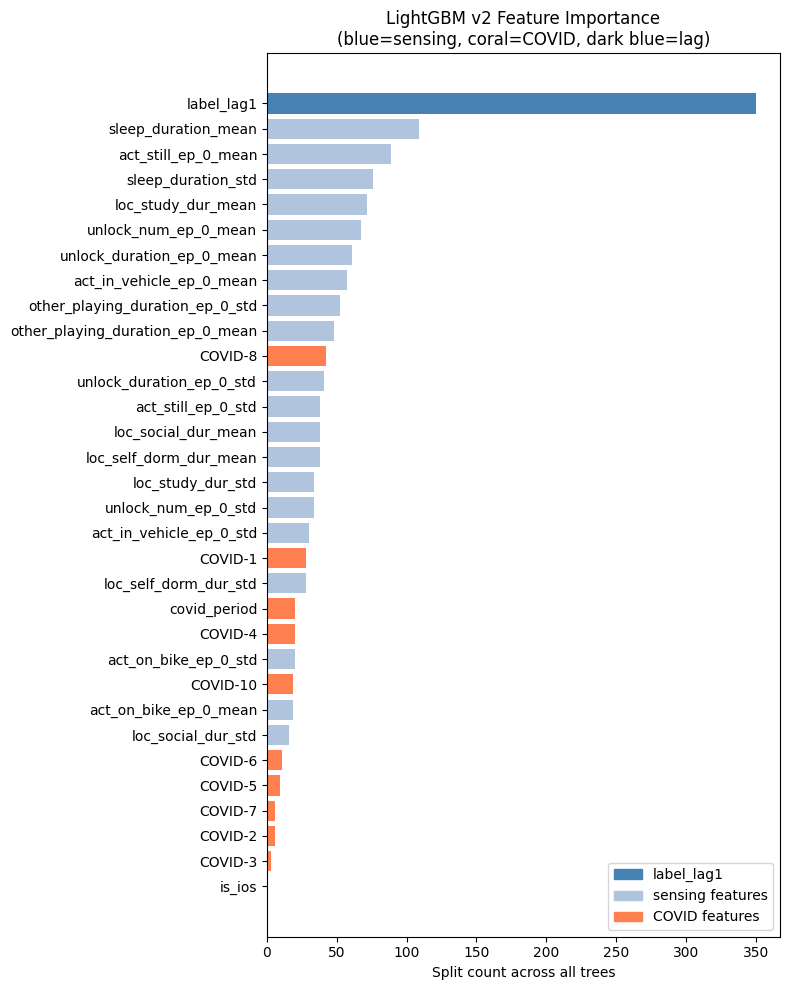


Top 10 most important features:
                         feature  importance
                      label_lag1         350
             sleep_duration_mean         109
             act_still_ep_0_mean          89
              sleep_duration_std          76
              loc_study_dur_mean          72
            unlock_num_ep_0_mean          67
       unlock_duration_ep_0_mean          61
        act_in_vehicle_ep_0_mean          57
 other_playing_duration_ep_0_std          52
other_playing_duration_ep_0_mean          48

COVID feature importance (coral bars):
     feature  importance
     COVID-8          42
     COVID-1          28
     COVID-4          20
covid_period          20
    COVID-10          19
     COVID-6          11
     COVID-5           9
     COVID-2           6
     COVID-7           6
     COVID-3           3


In [5]:
best_config = tuning_df.iloc[0]
print(f"Best config: lr={best_config['learning_rate']}, "
      f"depth={best_config['max_depth']}, leaves={best_config['num_leaves']}")

best_model_v2, best_metrics_v2 = train_lightgbm_v2(
    learning_rate=float(best_config["learning_rate"]),
    max_depth=int(best_config["max_depth"]),
    num_leaves=int(best_config["num_leaves"]),
    min_child_samples=int(best_config["min_child_samples"]),
    n_estimators=1000,
    run_name="v2_lgbm_experiment",
    register=False,
)

# Feature importance
fi = pd.DataFrame({
    "feature":    ALL_FEATURES,
    "importance": best_model_v2.feature_importances_,
}).sort_values("importance", ascending=True)

colors = []
for f in fi["feature"]:
    if f.startswith("COVID-") or f == "covid_period":
        colors.append("coral")
    elif f == "label_lag1":
        colors.append("steelblue")
    else:
        colors.append("lightsteelblue")

fig, ax = plt.subplots(figsize=(8, 10))
bars = ax.barh(fi["feature"], fi["importance"], color=colors)
ax.set_xlabel("Split count across all trees")
ax.set_title("LightGBM v2 Feature Importance\n"
             "(blue=sensing, coral=COVID, dark blue=lag)")

from matplotlib.patches import Patch
legend = [
    Patch(color="steelblue",      label="label_lag1"),
    Patch(color="lightsteelblue", label="sensing features"),
    Patch(color="coral",          label="COVID features"),
]
ax.legend(handles=legend, loc="lower right")
plt.tight_layout()
plt.savefig("../../outputs/figures/v2_lgbm_feature_importance.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nTop 10 most important features:")
print(fi.sort_values("importance", ascending=False).head(10).to_string(index=False))
print(f"\nCOVID feature importance (coral bars):")
covid_fi = fi[fi["feature"].str.startswith("COVID-") |
              (fi["feature"] == "covid_period")]
print(covid_fi.sort_values("importance", ascending=False).to_string(index=False))

In [6]:
print("=" * 55)
print("v2 EXPERIMENT SUMMARY")
print("=" * 55)
print(f"\nBest config: lr={best_config['learning_rate']}, "
      f"depth={best_config['max_depth']}, leaves={best_config['num_leaves']}")
print(f"\n{'Metric':<15} {'v2 value':>12}")
print("-" * 30)
print(f"{'val MAE':<15} {best_metrics_v2['val_mae']:>12.4f}")
print(f"{'test MAE':<15} {best_metrics_v2['test_mae']:>12.4f}")
print(f"{'val R2':<15} {best_metrics_v2['val_r2']:>12.4f}")
print(f"{'test R2':<15} {best_metrics_v2['test_r2']:>12.4f}")
print()
print("This run is NOT registered.")

v2 EXPERIMENT SUMMARY

Best config: lr=0.05, depth=4.0, leaves=15.0

Metric              v2 value
------------------------------
val MAE               8.6662
test MAE              9.4646
val R2                0.4654
test R2               0.4484

This run is NOT registered.
